In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


========= Train size: 0.6 =========
Критерий: entropy, Train size: 0.6
  Accuracy:  0.8380
  Precision: 0.7708
  Recall:    0.4670
  F1-score:  0.5816


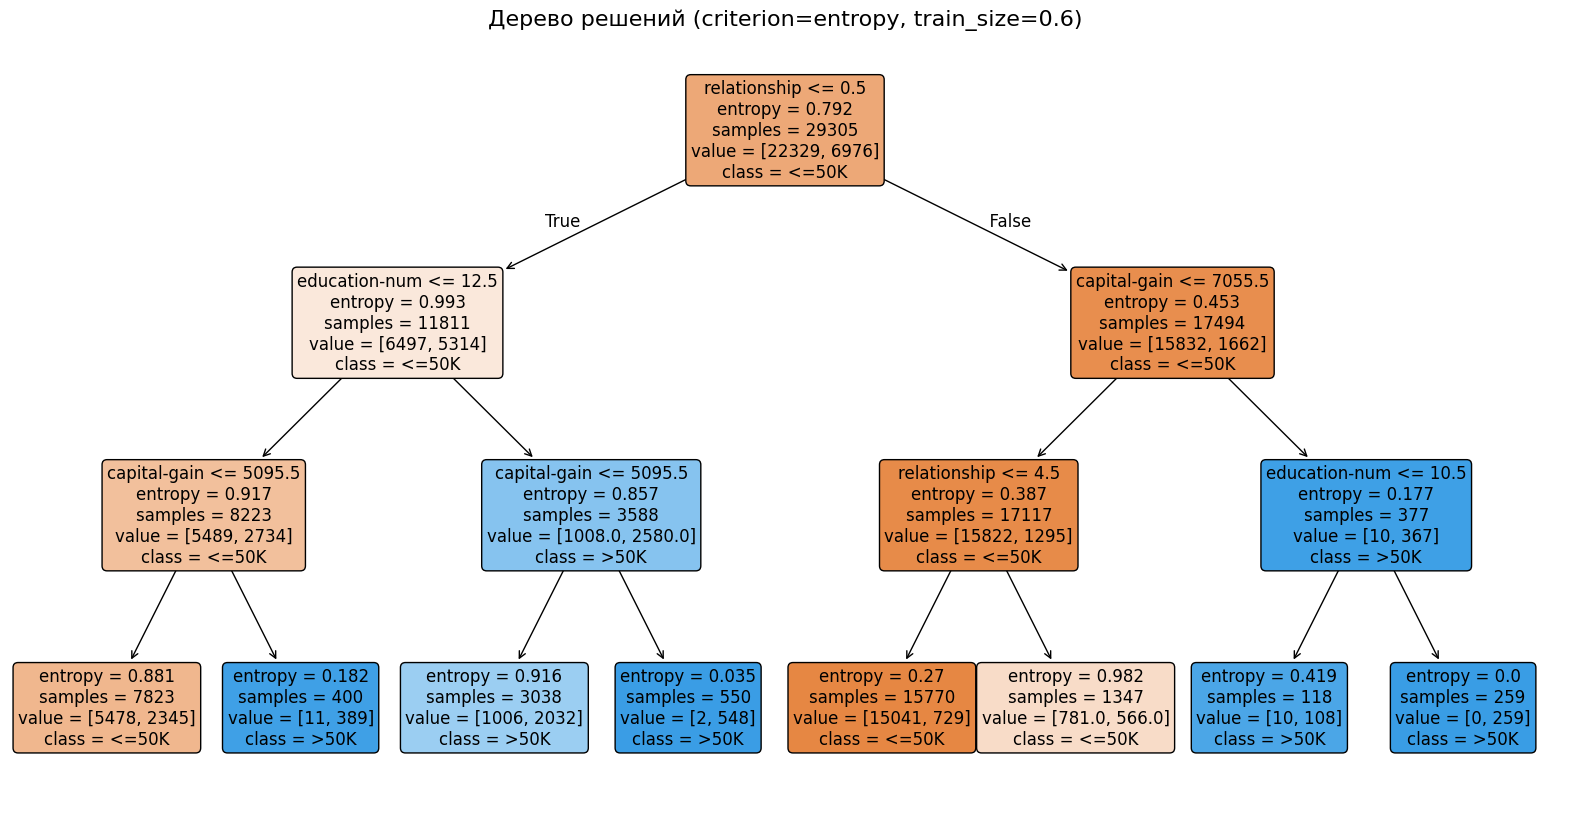


========= Train size: 0.7 =========
Критерий: entropy, Train size: 0.7
  Accuracy:  0.8366
  Precision: 0.7689
  Recall:    0.4639
  F1-score:  0.5787


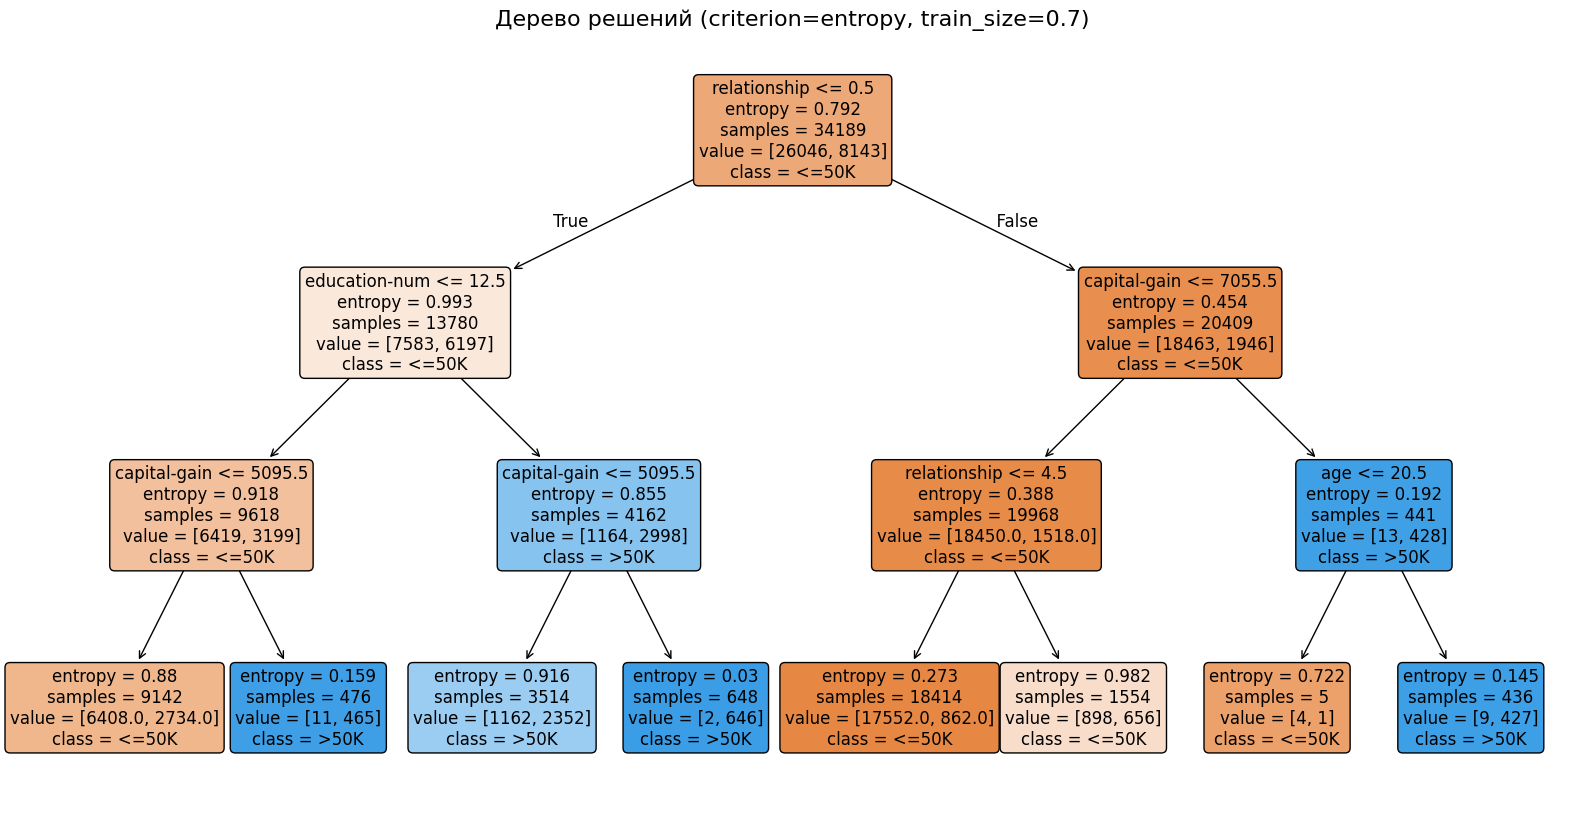


========= Train size: 0.8 =========
Критерий: entropy, Train size: 0.8
  Accuracy:  0.8372
  Precision: 0.7692
  Recall:    0.4641
  F1-score:  0.5789


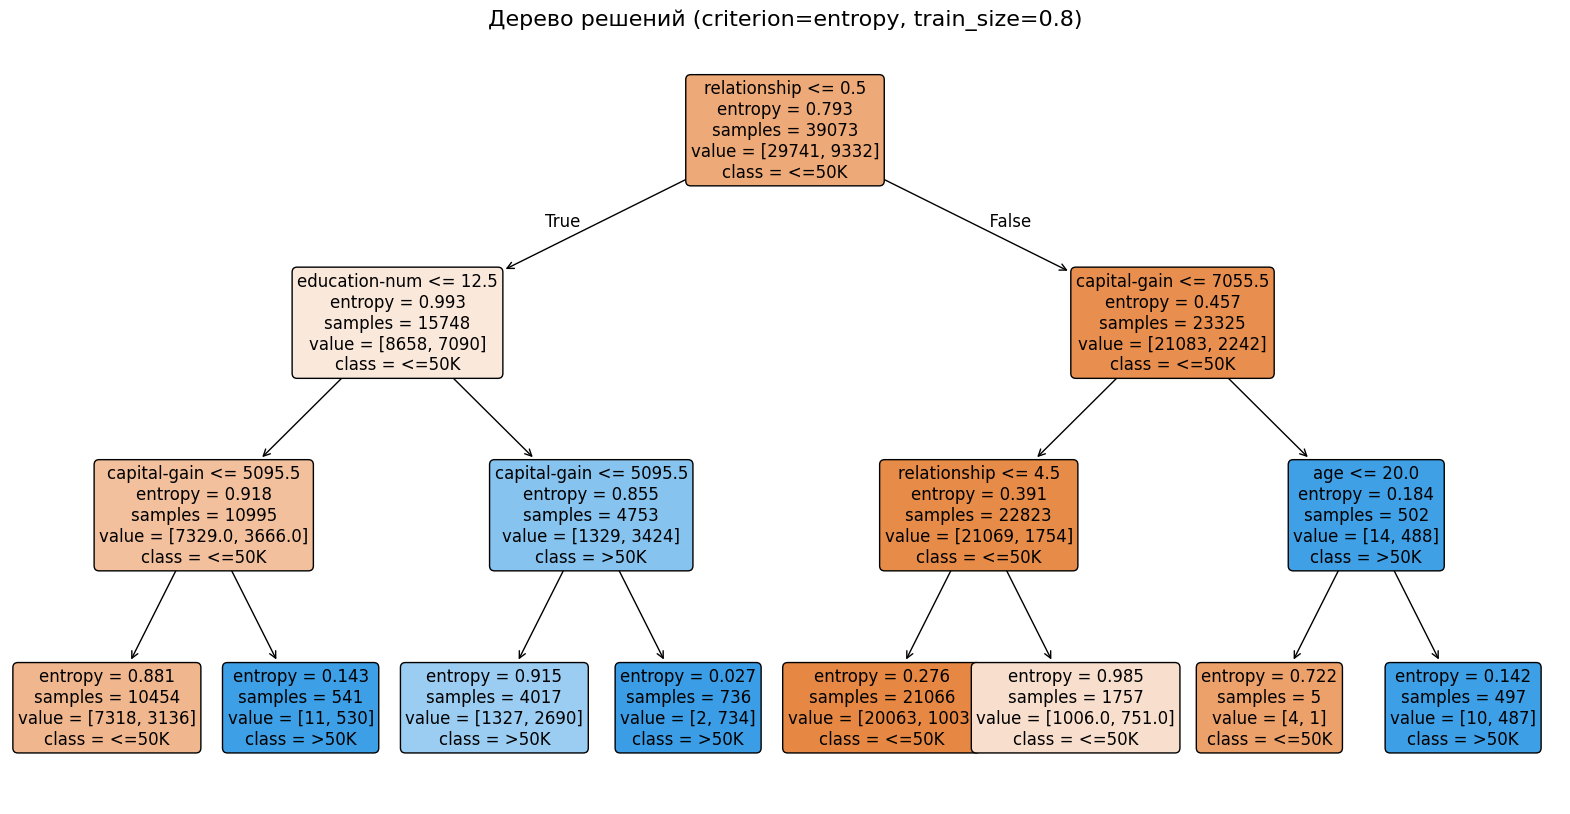


========= Train size: 0.9 =========
Критерий: entropy, Train size: 0.9
  Accuracy:  0.8356
  Precision: 0.7564
  Recall:    0.4548
  F1-score:  0.5680


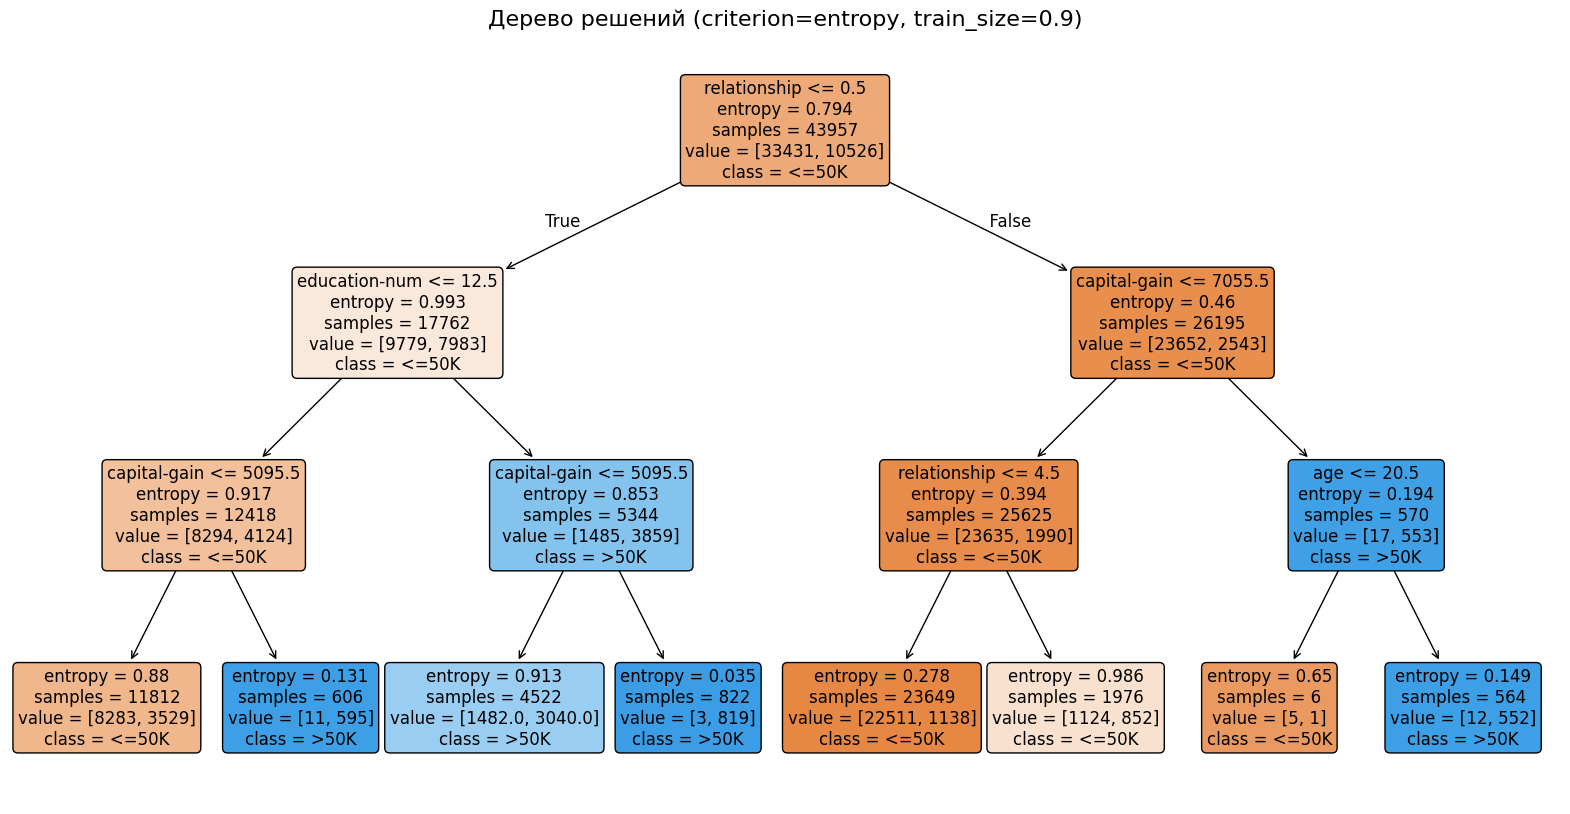

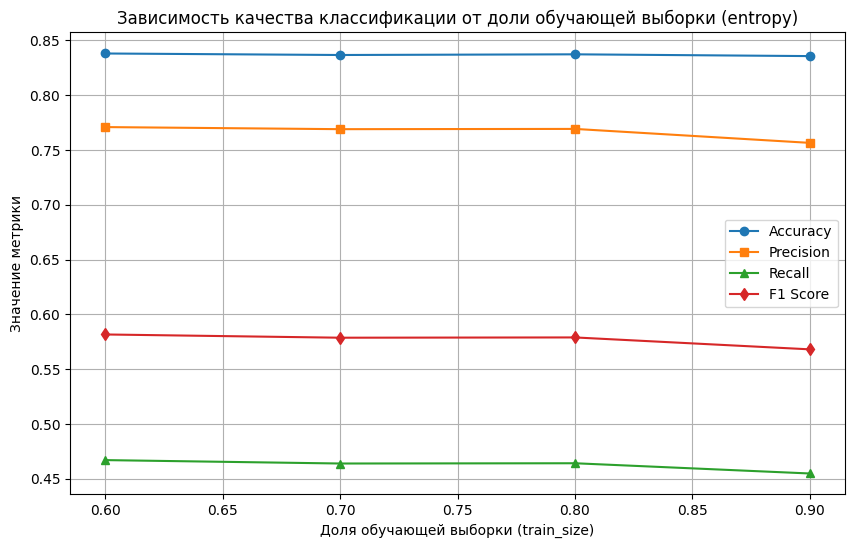

In [ ]:
# Задаём варианты соотношения обучающей выборки
train_sizes = [0.6, 0.7, 0.8, 0.9]
# Критерии разбиения
crit = 'entropy' # 'gini' или 'entropy'

# Задаём имена столбцов для набора данных Adult
column_names = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
                'marital-status', 'occupation', 'relationship', 'race', 'sex',
                'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

# Загрузка обучающей выборки
train = pd.read_csv('adult.data.csv', names=column_names, skipinitialspace=True)
# Загрузка тестовой выборки (пропускаем первую строку, если она содержит заголовок)
test = pd.read_csv('adult.test.csv', names=column_names, skipinitialspace=True, skiprows=1)

# Очистка меток целевой переменной
train['income'] = train['income'].str.strip()
test['income'] = test['income'].str.strip().str.replace('.', '', regex=False)

# Объединяем обучающую и тестовую выборки для последующего случайного разбиения
combined = pd.concat([train, test], ignore_index=True)

# Определяем категориальные столбцы (для всех переменных типа object)
categorical_cols = combined.select_dtypes(include=['object']).columns.tolist()

# Кодирование категориальных признаков с помощью LabelEncoder
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col])
    le_dict[col] = le

# Словарь для сохранения метрик для каждой комбинации критерия и train_size
results = {'crit': [], 'train_sizes': [], 'accuracy': [], 'precision': [], 'recall': [], 'f1': []}


# Перебор различных долей обучающей выборки
for train_size in train_sizes:
    print(f"\n========= Train size: {train_size} =========")
    train_encoded, test_encoded = train_test_split(combined, train_size=train_size, random_state=42)

    # Определяем признаки и целевую переменную
    X_train = train_encoded.drop('income', axis=1)
    y_train = train_encoded['income']
    X_test = test_encoded.drop('income', axis=1)
    y_test = test_encoded['income']

    clf = DecisionTreeClassifier(criterion=crit, max_depth=3, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # Вычисление метрик
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='binary', pos_label=1)
    rec = recall_score(y_test, y_pred, average='binary', pos_label=1)
    f1 = f1_score(y_test, y_pred, average='binary', pos_label=1)

    print(f"Критерий: {crit}, Train size: {train_size}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-score:  {f1:.4f}")

    # Сохранение результатов для построения диаграммы
    results['crit'].append(crit)
    results['train_sizes'].append(train_size)
    results['accuracy'].append(acc)
    results['precision'].append(prec)
    results['recall'].append(rec)
    results['f1'].append(f1)

    # Визуализация дерева решений для текущей комбинации параметров
    plt.figure(figsize=(20, 10))
    plot_tree(clf,
                feature_names=X_train.columns,
                class_names=['<=50K', '>50K'],
                filled=True,
                rounded=True,
                fontsize=12)
    plt.title(f"Дерево решений (criterion={crit}, train_size={train_size})", fontsize=16)
    plt.show()

# Построение диаграмм качества классификации в зависимости от доли обучающей выборки для каждого критерия
plt.figure(figsize=(10, 6))
plt.plot(results['train_sizes'], results['accuracy'], marker='o', label='Accuracy')
plt.plot(results['train_sizes'], results['precision'], marker='s', label='Precision')
plt.plot(results['train_sizes'], results['recall'], marker='^', label='Recall')
plt.plot(results['train_sizes'], results['f1'], marker='d', label='F1 Score')
plt.xlabel('Доля обучающей выборки (train_size)')
plt.ylabel('Значение метрики')
plt.title(f'Зависимость качества классификации от доли обучающей выборки ({crit})')
plt.legend()
plt.grid(True)
plt.show()
